In [1]:
import numpy as np
import pandas as pd

from scipy import odr
from scipy.interpolate import griddata
import scipy.ndimage as nd
from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter

import astropy.units as u
from astropy import wcs
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.visualization import AsinhStretch, make_rgb, AsymmetricPercentileInterval, simple_norm, SimpleNorm

import gala.coordinates as gc

import matplotlib.pyplot as plt
import matplotlib.gridspec as gs
import sys


In [2]:
#  loading the two image files from ACS F555W and ACS F814W
filename555= '../Data_HST/hst_16890_03_acs_wfc_f555w_jesd03'
hdu_f555w = fits.open(filename555+'_drc.fits')
im555 = fits.getdata(filename555+'_drc.fits')


filename814= '../Data_HST/hst_16890_03_acs_wfc_f814w_jesd03'
hdu_f814w = fits.open(filename814+'_drc.fits')
im814 = fits.getdata(filename814+'_drc.fits')

wcs_HST = wcs.WCS(hdu_f555w[1].header)

In [3]:
CFHT_G = fits.open('../Data_CFHT_cropped/CFHTLS_W_g_141202+514231_T0007_MEDIAN_cutout.fits')
wcs_CFHT = wcs.WCS(CFHT_G[0].header)
G_im = CFHT_G[0].data


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


In [4]:
#read skycoords from csv
coords_df = pd.read_csv("../Clicked_points/streamcoords.ecsv", comment='#',usecols=['ra','dec'])
ra_list = coords_df['ra'].values
dec_list = coords_df['dec'].values

# Use first and last points as endpoints for GreatCircleICRSFrame
first_point = SkyCoord(ra=coords_df.iloc[0]['ra'], dec=coords_df.iloc[0]['dec'], unit='deg')
last_point = SkyCoord(ra=coords_df.iloc[-1]['ra'], dec=coords_df.iloc[-1]['dec'], unit='deg')

# Compute pole as cross product
pole = first_point.cartesian.cross(last_point.cartesian)

# Create the frame
phiphifr = gc.GreatCircleICRSFrame(pole=pole, origin=first_point)

# Transform all points
all_coords = SkyCoord(ra=coords_df['ra'], dec=coords_df['dec'], unit='deg')
transformed = all_coords.transform_to(phiphifr)

# Add new coordinates
coords_df['phi1'] = transformed.phi1.degree
coords_df['phi2'] = transformed.phi2.degree

In [5]:
# Transform image to phiphi coordinate system
def transform_image(image, tele='HST', image_wcs=None):
    # Create meshgrid indices for coordinate calculation
    ny, nx = image.shape
    y, x = np.mgrid[0:ny, 0:nx]

    if tele == 'HST':
        # Crop image to speed up everything later
        crop_im = image[3000:3500, 2200:2800]
        # Need to calculate sky coords for total image to use what's in header, then crop
        sky_coords = wcs_HST.pixel_to_world(x, y)[3000:3500, 2200:2800]
    elif tele == 'CFHT':
        crop_im = image
        if image_wcs is None:
            image_wcs = wcs_CFHT
        sky_coords = image_wcs.pixel_to_world(x, y)
    else:
        print('wrong frame')
        return

    # Transform to phiphi system and get new coord arrays in degrees
    rotated = sky_coords.transform_to(phiphifr)
    phi1 = rotated.phi1.deg
    phi2 = rotated.phi2.deg

    # Flatten input for interpolation
    points = np.vstack([phi1.ravel(), phi2.ravel()]).T
    values = crop_im.ravel()
    ncy, ncx = crop_im.shape

    # Make linear grid corresponding to cropped image
    phi1_lin = np.linspace(np.nanmin(phi1), np.nanmax(phi1), ncx)
    phi2_lin = np.linspace(np.nanmin(phi2), np.nanmax(phi2), ncy)

    # For imshow plotting
    ext = [phi1_lin[0], phi1_lin[-1], phi2_lin[0], phi2_lin[-1]]

    # Making a meshgrid
    grid_phi1, grid_phi2 = np.meshgrid(phi1_lin, phi2_lin)

    # Interpolate
    phi_image = griddata(points, values, (grid_phi1, grid_phi2), method='linear', rescale=True)
    # phi_image is now image rotated into the phiphi frame
    return phi_image, ext

In [6]:
phi_814, extent_814_phi = transform_image(im814)
phi_im, extent_phi = transform_image(im814+im555)

extent_814_arc = (np.array(extent_814_phi)*u.deg.to(u.arcsec)).astype(list)

im_phi1 = np.linspace(extent_814_phi[0], extent_814_phi[1], len(phi_814[0]))
im_phi2 = np.linspace(extent_814_phi[2], extent_814_phi[3], len(phi_814))

phi_G_im, extent_G_phi = transform_image(G_im, tele = 'CFHT')
extent_G_arc = (np.array(extent_G_phi)*u.deg.to(u.arcsec)).astype(list)

im_phi1_G = np.linspace(extent_G_phi[0], extent_G_phi[1], len(phi_G_im[0]))
im_phi2_G = np.linspace(extent_G_phi[2], extent_G_phi[3], len(phi_G_im))#-0.0001


In [7]:
# Fit a polynomial to clicked points along the stream

# Load points and transform to phiphi coords
stream_points = pd.read_csv('../Clicked_points/newnew_stream.csv')
stream_wsc_HST = wcs_HST.pixel_to_world(stream_points.x, stream_points.y)

stream_phi1 = stream_wsc_HST.transform_to(phiphifr).phi1.value
stream_phi2 = stream_wsc_HST.transform_to(phiphifr).phi2.value

# Usiing scipy.odr to fit polynomial to the points
data = odr.Data(stream_phi1, stream_phi2)
odr_obj = odr.ODR(data, odr.polynomial(5)) # number is order of polynomial
output = odr_obj.run()

# make np.poly1d object from fit 
poly = np.poly1d(output.beta[::-1])

In [8]:
# for plotting the stream track
x_stream_phi = np.linspace(stream_phi1[0]+0.00005, stream_phi1[-1]+0.0002, 100)

In [9]:
# Flatten stream by perpendicular slices
def create_perpendicular_slices(image, poly, phi1, phi2, phi1min, phi1max, n_steps, width=0.002):
    # Over-sample the polynomial to have a fine grid of points to pick from
    step_size = np.abs(phi1max-phi1min) / n_steps

    phi1_fine = np.arange(phi1min, phi1max, step_size/5)
    poly_fine = poly(phi1_fine)

    # For the first point, calculate tangential and perpendicular vectors
    p1, p2 = phi1_fine[0], poly_fine[0]
    dpoly = poly.deriv()

    sampled_mask = np.full(image.shape, np.nan)
    phi1_sampled = []
    slices = []
    count = 0
    while p1 <= phi1max:
        # calculate tangential vector 
        slope = dpoly(p1)
        tangent = np.array([1, slope])
        tangent /= np.linalg.norm(tangent)  # Normalize to unit vector
        # Calculaate perpendicular vector (rotate tangent by 90 degrees)
        perp = np.array([-tangent[1], tangent[0]])
        
        # Sample points along the perpendicular direction, centered at (p1, p2)
        # Width is in pixels, so offsets are just pixel indices
        offsets = np.arange(-width//2, width//2)
        # For each offset, move in perp direction, but get pixel indices directly
        # Map (p1, p2) in degrees to pixel indices
        p1_pix = np.interp(p1, phi1, np.arange(len(phi1)))
        p2_pix = np.interp(p2, phi2, np.arange(len(phi2)))

        # For each offset, get pixel coordinates along perp
        coords_pix = np.array([p1_pix, p2_pix])[:, None] + perp[:, None] * offsets
        # Use map_coordinates to sample the image at these points
        sampled_values = nd.map_coordinates(image, [coords_pix[1], coords_pix[0]], order=1, mode='nearest')
        slices.append(sampled_values)
        

        for k,j in zip(coords_pix[0], coords_pix[1]):
            sampled_mask[int(j),int(k)] = image[int(j),int(k)]

        phi1_sampled.append(p1)

        # Take step along tangent vector
        next_point = np.array([p1, p2]) + step_size * tangent
        p1, p2 = next_point[0], next_point[1]
        count +=1
    print(count)
    return phi1_sampled, np.array(slices), sampled_mask


In [10]:
def gaussian_with_offset(x, amplitude, mean, stddev, m, b):
    return amplitude * np.exp(-0.5 * ((x - mean) / stddev) ** 2) + m*x + b

# Fit function
def fit_gaussian_with_offset(x_data, y_data, y_err = None, initial_guess=None):
    if initial_guess is None:
        amplitude_guess = np.max(y_data) - np.mean(y_data)
        mean_guess = x_data[np.argmax(y_data)]
        stddev_guess = (x_data[-1] - x_data[0]) / 2  # Rough estimate of spread
        b_guess = np.min(y_data)
        m_guess = (y_data[-1]- y_data[0])/(x_data[-1]-x_data[0])
        initial_guess = (amplitude_guess, mean_guess, stddev_guess, m_guess, b_guess)
    
    # Set bounds to ensure amplitude is positive
    bounds = ((0, -np.inf, 0, -np.inf, -np.inf), (1000, np.inf, np.inf, np.inf, np.inf))
    popt, pcov = curve_fit(gaussian_with_offset, x_data, y_data, sigma= y_err, absolute_sigma=True, p0=initial_guess, bounds=bounds)

    return popt, pcov


In [12]:
w_HST = 150
p1_samp_814, slices_814, mask_814 = create_perpendicular_slices(phi_im, poly, im_phi1, im_phi2, stream_phi1[0]+0.00005,
                                                    stream_phi1[-1]+0.0002, n_steps = 400, width=w_HST)

w_CFHT = int(w_HST*0.05/0.187)
p1_samp_G, slices_G, mask_G = create_perpendicular_slices(
    phi_G_im, poly, im_phi1_G, im_phi2_G, stream_phi1[0]+0.00005,
                                                    stream_phi1[-1]+0.0002, n_steps=40, width=w_CFHT)


flatslice_814 = slices_814.T
flatslice_G = slices_G.T

466
47


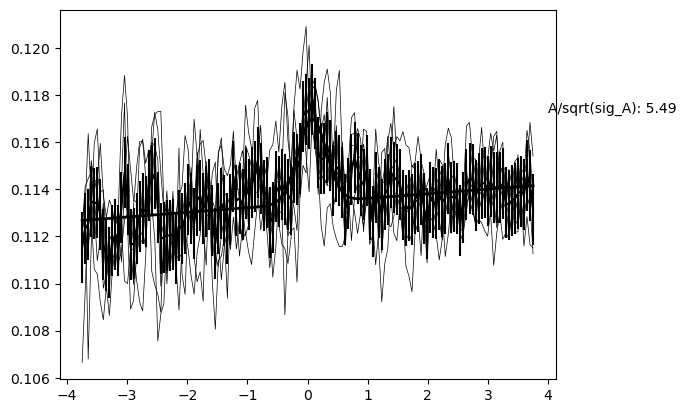

In [13]:
segs = 6
seglen = len(flatslice_814[0])/segs
allmeans = []
x_HST = np.linspace(-w_HST/2, w_HST/2, w_HST)*0.05 #in arcsec
x_HST_pc = (x_HST*u.arcsec.to(u.rad)*35.2e6*u.pc).value


fig, ax = plt.subplots()
start = 0
colin = 0
for seg in np.arange(seglen,len(flatslice_814[0])+1,seglen):
    segmean = np.nanmean(flatslice_814[:,int(start):int(seg)], axis=1)
    allmeans.append(segmean)
    ax.plot(x_HST, segmean, c = 'k', lw=0.5)#colors[colin])
    start += seglen
    colin +=1

ferr = np.mean((np.std(allmeans, axis=0))) * np.ones(len(x_HST))
ax.errorbar(x_HST, np.mean(allmeans, axis=0), yerr=ferr, c='k')
gaus_p, gaus_c = fit_gaussian_with_offset(x_HST, np.mean(allmeans, axis=0),y_err = ferr)
amplitude = gaus_p[0]
amplitude_error = np.sqrt(gaus_c[0][0])
signif = amplitude / amplitude_error
ax.text(4,0.99*np.max(segmean), f'A/sqrt(sig_A): {signif:.2f}', fontsize=10)
ax.plot(x_HST, gaussian_with_offset(x_HST, *gaus_p), 'k', lw=2)
#ax.vlines([-7.5+gaus_p[1],7.5+gaus_p[1]], 0.108,0.123)
#ax.vlines([-12.5+gaus_p[1],12.5+gaus_p[1]], 0.108,0.123, 'r')



In [14]:
conv = u.arcsec.to(u.rad)*35.2e6*u.pc
amp_814, mean_814, stddev_814, m_814, b_814 = gaus_p
amp_c_814, mean_c_814, stddev_c_814, m_c_814, b_c_814 = gaus_c[0,0], gaus_c[1,1], gaus_c[2,2], gaus_c[3,3], gaus_c[4,4]
amp_814/np.sqrt(amp_c_814), amp_814, np.sqrt(stddev_c_814)*conv

(5.486561324725065, 0.0035433491383598257, <Quantity 8.67440768 pc>)

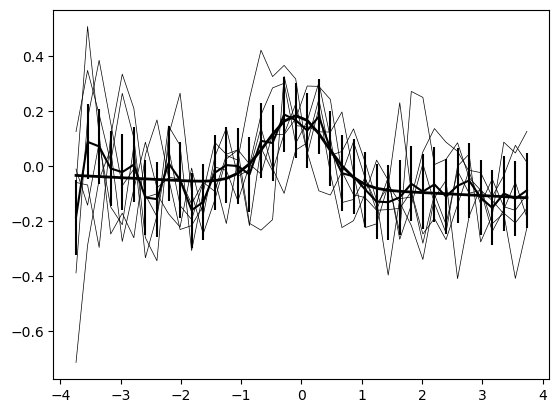

In [15]:
segs = 6
seglen = len(flatslice_G[0])/segs
allmeans_G = []
x_CFHT = np.linspace(-w_CFHT/2, w_CFHT/2, w_CFHT)*0.187 #in arcsec
x_CFHT_pc = (x_CFHT*u.arcsec.to(u.rad)*35.2e6*u.pc).value

fig, ax = plt.subplots()
start = 0
colin = 0
for seg in np.arange(seglen,len(flatslice_G[0])+1,seglen):
    segmean = np.nanmean(flatslice_G[:,int(start):int(seg)], axis=1)
    allmeans_G.append(segmean)
    ax.plot(x_CFHT, segmean, c = 'k', lw=0.5)#colors[colin])
    start += seglen
    colin +=1

ferr_G = np.mean((np.std(allmeans_G, axis=0))) * np.ones(len(x_CFHT))
ax.errorbar(x_CFHT, np.mean(allmeans_G, axis=0), yerr=ferr_G, c='k')
gaus_p_G, gaus_c_G = fit_gaussian_with_offset(x_CFHT, np.mean(allmeans_G, axis=0),y_err = ferr_G)
amplitude = gaus_p_G[0]
amplitude_error = np.sqrt(gaus_c_G[0][0])
signif = amplitude / amplitude_error
#ax.text(4,0.99*np.max(segmean), f'A/sqrt(sig_A): {signif:.2f}', fontsize=10)
#ax.plot(x_CFHT*u.arcsec.to(u.rad)*35.2e6*u.pc, gaussian_with_offset(x_CFHT, *gaus_p_G)*u.arcsec.to(u.rad)*35.2e6*u.pc, 'k', lw=2)
ax.plot(x_CFHT, gaussian_with_offset(x_CFHT, *gaus_p_G), 'k', lw=2)



In [17]:
amp_G, mean_G, stddev_G, m_G, b_G = gaus_p_G
amp_c_G, mean_c_G, stddev_c_G, m_c_G, b_c_G = gaus_c_G[0,0], gaus_c_G[1,1], gaus_c_G[2,2], gaus_c_G[3,3], gaus_c_G[4,4]
np.sqrt(stddev_c_G)*conv

<Quantity 32.32024833 pc>

In [18]:
sig = gaus_p[2]
sig_G = gaus_p_G[2]
sig_pc = (sig)*u.arcsec.to(u.rad)*35.2e6*u.pc
sig_pc_G = (sig_G)*u.arcsec.to(u.rad)*35.2e6*u.pc

mean_pc = gaus_p[1]*u.arcsec.to(u.rad)*35.2e6*u.pc
mean_pc_G = gaus_p_G[1]*u.arcsec.to(u.rad)*35.2e6*u.pc

FWHM = 2*np.sqrt(2*np.log(2))*sig
FWHM_G = 2*np.sqrt(2*np.log(2))*sig_G
FWHM_pc = FWHM*u.arcsec.to(u.rad)*35.2e6*u.pc
FWHM_pc_G = FWHM_G*u.arcsec.to(u.rad)*35.2e6*u.pc


2*sig, 2*sig_G, sig_pc, sig_pc_G, FWHM, FWHM_G, FWHM_pc, FWHM_pc_G

(0.47286722289504757,
 0.9937856946798981,
 <Quantity 40.34843983 pc>,
 <Quantity 84.79695855 pc>,
 0.556758607555688,
 1.1700932371486155,
 <Quantity 95.01331489 pc>,
 <Quantity 199.68157776 pc>)

In [19]:
phi_814_normalised = simple_norm(phi_814, stretch='asinh', min_percent=50, max_percent=75, asinh_a=0.3)(phi_814)
phi_G_normalised = simple_norm(phi_G_im, stretch='asinh', min_percent=30, max_percent=75, asinh_a=0.3)(phi_G_im)    

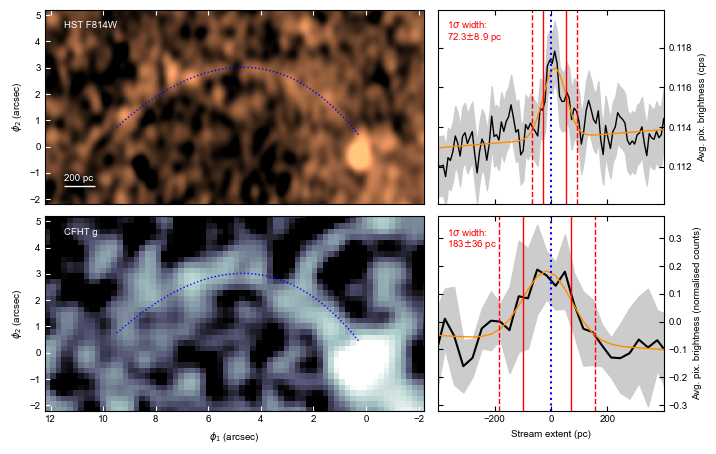

In [ ]:
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 7,
})

FlatFig = plt.figure(figsize = (183/25.4, 183/25.4*6/9.5))
spec = FlatFig.add_gridspec(2,2, width_ratios = [8.5,4.8], height_ratios=[1,1])

hst = FlatFig.add_subplot(spec[0,0])
cfht = FlatFig.add_subplot(spec[1,0])
whst = FlatFig.add_subplot(spec[0,1])
wcfht= FlatFig.add_subplot(spec[1,1], sharex=whst)

################ HST image
hst.imshow(gaussian_filter(phi_814, 3), norm = simple_norm(phi_814, stretch='asinh', min_percent=35, max_percent=90, asinh_a=0.3), cmap='copper', aspect=1, origin='lower', extent=extent_814_arc)
#hst.imshow(gaussian_filter(phi_814_normalised, 3), cmap='copper', aspect=1, origin='lower', extent=extent_814_arc)

hst.plot(x_stream_phi*u.deg.to(u.arcsec), poly(x_stream_phi)*u.deg.to(u.arcsec), c='b',ls=':', lw = 1.)
hst.set_xlim(12.2,-2.2)
hst.set_ylim(-2.2,5.2)


################ CFHT image 
cfht.imshow(gaussian_filter(phi_G_im, 1.5), norm = simple_norm(phi_G_im, stretch='asinh', min_percent=30, max_percent=80), cmap='bone', aspect=1, origin='lower', extent=extent_G_arc)
#cfht.imshow(gaussian_filter(phi_G_normalised, 2), cmap='bone', aspect=1, origin='lower', extent=extent_G_arc)

cfht.plot(x_stream_phi*u.deg.to(u.arcsec), poly(x_stream_phi)*u.deg.to(u.arcsec), c='b',ls=':', lw = 1.)
cfht.set_xlim(12.2,-2.2)
cfht.set_ylim(-2.2,5.2)

################ Width HST
whst.plot(x_HST_pc, np.mean(allmeans, axis=0), 'k-', lw=1)
whst.fill_between(x_HST_pc, np.mean(allmeans, axis=0)+ferr, np.mean(allmeans, axis=0)-ferr, color='0.8')
whst.plot(x_HST_pc, gaussian_with_offset(x_HST, *gaus_p), 'darkorange', lw=1)

whst.axvline(mean_pc.value+sig_pc.value, color='r', ls='-', lw=1)
whst.axvline(mean_pc.value-sig_pc.value, color='r', ls='-', lw=1)
whst.axvline(mean_pc.value+2*sig_pc.value, color='r', ls='--', lw=1)
whst.axvline(mean_pc.value-2*sig_pc.value, color='r', ls='--', lw=1) 
whst.axvline(0, color='b', ls=':')

whst.set_ylim(0.1101,0.1199)


################ Width CFHT
wcfht.plot(x_CFHT_pc, np.mean(allmeans_G, axis=0),'k-')
wcfht.plot(x_CFHT_pc, gaussian_with_offset(x_CFHT, *gaus_p_G), 'darkorange', lw=1)
wcfht.fill_between(x_CFHT_pc, np.mean(allmeans_G, axis=0)+np.std(allmeans_G, axis=0), np.mean(allmeans_G, axis=0)-np.std(allmeans_G, axis=0), color='0.8')

wcfht.axvline(mean_pc_G.value+sig_pc_G.value, color='r', ls='-', lw=1)
wcfht.axvline(mean_pc_G.value-sig_pc_G.value, color='r', ls='-', lw=1)
wcfht.axvline(mean_pc_G.value+2*sig_pc_G.value, color='r', ls='--', lw=1)
wcfht.axvline(mean_pc_G.value-2*sig_pc_G.value, color='r', ls='--', lw=1)
wcfht.axvline(0, color='b', ls=':')

wcfht.set_xlim(-399,399)
wcfht.set_ylim(-0.32,0.38)

################ Labels
hst.tick_params(axis='both', bottom=False, top=True, labelbottom=False, labeltop=False, direction='in', colors='w', labelcolor='k')
hst.set_ylabel(r'$\phi_2$ (arcsec)')

cfht.tick_params(axis='both', direction='in', colors='w', labelcolor='k')
cfht.set_xlabel(r'$\phi_1$ (arcsec)', color='k')
cfht.set_ylabel(r'$\phi_2$ (arcsec)', color='k')

whst.tick_params(axis='both', right=True, labelright=True, labelleft=False, bottom=True, top=True, labelbottom=False, direction='in')
wcfht.tick_params(axis='both', right=True, labelleft=False, labelright=True, top=True, bottom=True, direction='in')

whst.yaxis.set_label_position("right")
wcfht.yaxis.set_label_position("right")

wcfht.set_ylabel('Avg. pix. brightness (normalised counts)')
whst.set_ylabel('Avg. pix. brightness (cps)')
wcfht.set_xlabel('Stream extent (pc)')

################ Text
hst.text(11.5, 4.5, 'HST F814W', color='w')

cfht.text(11.5, 4.5, 'CFHT g', color='w')

whst.text(-370, 0.119, r'1$\sigma$ width:', color='r')
whst.text(-370, 0.1184,r'72.3$\pm $8.9 pc', color='r')

wcfht.text(-370, 0.31, r'1$\sigma$ width:', color='r')
wcfht.text(-370, 0.27, r'183$\pm $36 pc', color='r')


hst.hlines(-1.5,11.5, 11.5-200/8.53*0.05, color='w', linewidth=1)
hst.text(11.5, -1.3,'200 pc', color='w')
plt.tight_layout()
#FlatFig.savefig('../Figures/Phigure_new.eps', bbox_inches='tight')


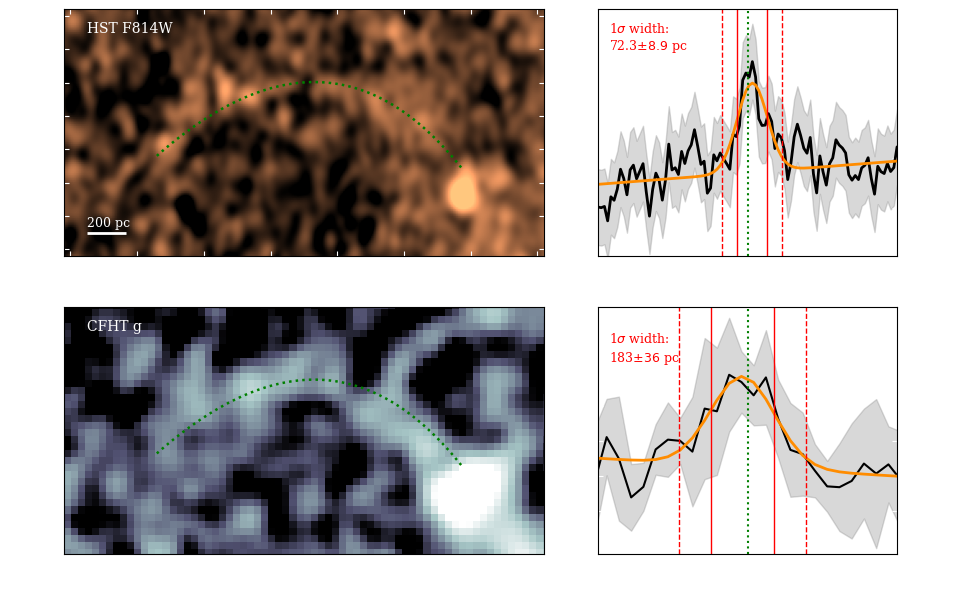

In [31]:
FlatFig = plt.figure(figsize = (9.6,6), constrained_layout=True, facecolor='none')
spec = FlatFig.add_gridspec(2,2, width_ratios = [8.5,4.8], height_ratios=[1,1])

hst = FlatFig.add_subplot(spec[0,0])
cfht = FlatFig.add_subplot(spec[1,0])
whst = FlatFig.add_subplot(spec[0,1])
wcfht= FlatFig.add_subplot(spec[1,1], sharex=whst)

################ HST image
hst.imshow(gaussian_filter(phi_814, 3), norm = simple_norm(phi_814, stretch='asinh', min_percent=35, max_percent=90, asinh_a=0.3), cmap='copper', aspect=1, origin='lower', extent=extent_814_arc)
#hst.imshow(gaussian_filter(phi_814_normalised, 3), cmap='copper', aspect=1, origin='lower', extent=extent_814_arc)

hst.plot(x_stream_phi*u.deg.to(u.arcsec), poly(x_stream_phi)*u.deg.to(u.arcsec), c='g',ls=':', lw = 1.8, alpha=1)
hst.set_xlim(12.2,-2.2)
hst.set_ylim(-2.2,5.2)


################ CFHT image 
cfht.imshow(gaussian_filter(phi_G_im, 1.5), norm = simple_norm(phi_G_im, stretch='asinh', min_percent=30, max_percent=80), cmap='bone', aspect=1, origin='lower', extent=extent_G_arc)
#cfht.imshow(gaussian_filter(phi_G_normalised, 2), cmap='bone', aspect=1, origin='lower', extent=extent_G_arc)

cfht.plot(x_stream_phi*u.deg.to(u.arcsec), poly(x_stream_phi)*u.deg.to(u.arcsec), c='g',ls=':', lw = 1.8, alpha=1)
cfht.set_xlim(12.2,-2.2)
cfht.set_ylim(-2.2,5.2)

################ Width HST
whst.plot(x_HST_pc, np.mean(allmeans, axis=0), 'k-', lw=2)
whst.fill_between(x_HST_pc, np.mean(allmeans, axis=0)+ferr, np.mean(allmeans, axis=0)-ferr, color='gray', alpha=0.3)
whst.plot(x_HST_pc, gaussian_with_offset(x_HST, *gaus_p), 'darkorange', lw=2)

whst.axvline(mean_pc.value+sig_pc.value, color='r', ls='-', lw=1)
whst.axvline(mean_pc.value-sig_pc.value, color='r', ls='-', lw=1)
whst.axvline(mean_pc.value+2*sig_pc.value, color='r', ls='--', lw=1)
whst.axvline(mean_pc.value-2*sig_pc.value, color='r', ls='--', lw=1) 
whst.axvline(0, color='g', ls=':')

whst.set_ylim(0.1101,0.1199)


################ Width CFHT
wcfht.plot(x_CFHT_pc, np.mean(allmeans_G, axis=0),'k-')
wcfht.plot(x_CFHT_pc, gaussian_with_offset(x_CFHT, *gaus_p_G), 'darkorange', lw=2)
wcfht.fill_between(x_CFHT_pc, np.mean(allmeans_G, axis=0)+np.std(allmeans_G, axis=0), np.mean(allmeans_G, axis=0)-np.std(allmeans_G, axis=0), color='gray', alpha=0.3)

wcfht.axvline(mean_pc_G.value+sig_pc_G.value, color='r', ls='-', lw=1)
wcfht.axvline(mean_pc_G.value-sig_pc_G.value, color='r', ls='-', lw=1)
wcfht.axvline(mean_pc_G.value+2*sig_pc_G.value, color='r', ls='--', lw=1)
wcfht.axvline(mean_pc_G.value-2*sig_pc_G.value, color='r', ls='--', lw=1)
wcfht.axvline(0, color='g', ls=':')

wcfht.set_xlim(-400,400)
wcfht.set_ylim(-0.32,0.38)

################ Labels
hst.tick_params(axis='x', bottom=True, top=True, labelbottom=True, direction='in')
hst.tick_params(axis='y', left=True, right=True, direction='in')

hst.set_ylabel(r'$\phi_2$ ["]', font='serif', color='w')
hst.set_xlabel(r'$\phi_1$ ["]', font='serif', color='w')


cfht.tick_params(axis='x', labelfontfamily = 'serif', labelsize=10)
cfht.tick_params(axis='y', labelfontfamily = 'serif', labelsize=10)
cfht.set_ylabel(r'$\phi_2$ ["]', font='serif', color='w')
cfht.set_xlabel(r'$\phi_1$ ["]', font='serif', color='w')

whst.tick_params(axis='y', right=True, labelright=True, labelleft=False, direction='in')
whst.tick_params(axis='x', bottom=True, top=True, labelbottom=True, direction='in')
wcfht.tick_params(axis='y', right=True, labelleft=False, labelright=True, direction='in')
wcfht.tick_params(axis='x', labelfontfamily = 'serif', top=True, labelsize=10, direction='in')

whst.yaxis.set_label_position("right")
wcfht.yaxis.set_label_position("right")

wcfht.set_ylabel('Avg. pix. brightness', font='serif', color='w')
whst.set_ylabel('Avg. pix. brightness [cps]', font='serif', color='w')
wcfht.set_xlabel('Stream extent [pc]', font='serif', color='w')
whst.set_xlabel('Stream extent [pc]', font='serif', color='w')


# Make ticks and tick labels white on all axes
for ax in [hst, cfht, whst, wcfht]:
    ax.tick_params(axis='both', colors='w', labelcolor='w')

################ Text
hst.text(11.5, 4.5, 'HST F814W', color='w', font='serif')

cfht.text(11.5, 4.5, 'CFHT g', color='w', font='serif')

whst.text(-370, 0.119, r'1$\sigma$ width:', fontsize=9, color='r', font='serif')
whst.text(-370, 0.1183,r'72.3$\pm 8.9$ pc', fontsize=9, color='r', font='serif')

wcfht.text(-370, 0.28, r'1$\sigma$ width:', fontsize=9, color='r', font='serif')
wcfht.text(-370, 0.225, r'183$\pm 36$ pc', fontsize=9, color='r', font='serif')


hst.hlines(-1.5,11.5, 11.5-200/8.53*0.05, color='w', linewidth=2)
hst.text(11.5, -1.3,'200 pc', color='w', font='serif',fontsize=9)

FlatFig.patch.set_alpha(0)
FlatFig.savefig('Figures/Phigure_new_transparent.png', dpi=600, bbox_inches='tight', transparent=False)
